In [ ]:
def _fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except:
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    string = new_str
    return string

def _fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        a = int(a)
        b = int(b)
        assert string == "{}/{}".format(a, b)
        new_string = "\\frac{" + str(a) + "}{" + str(b) + "}"
        return new_string
    except:
        return string

def _remove_right_units(string):
    # "\\text{ " only ever occurs (at least in the val set) when describing units
    if "\\text{ " in string:
        splits = string.split("\\text{ ")
        assert len(splits) == 2
        return splits[0]
    else:
        return string

def _fix_sqrt(string):
    if "\\sqrt" not in string:
        return string
    splits = string.split("\\sqrt")
    new_string = splits[0] 
    for split in splits[1:]:
        if split[0] != "{":
            a = split[0]
            new_substr = "\\sqrt{" + a + "}" + split[1:]
        else:
            new_substr = "\\sqrt" + split
        new_string += new_substr
    return new_string

def _strip_string(string):
    # linebreaks  
    string = string.replace("\n", "")
    #print(string)

    # remove inverse spaces
    string = string.replace("\\!", "")
    #print(string)

    # replace \\ with \
    string = string.replace("\\\\", "\\")
    #print(string)

    # replace tfrac and dfrac with frac
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")
    #print(string)

    # remove \left and \right
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")
    #print(string)
    
    # Remove circ (degrees)
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")

    # remove dollar signs
    string = string.replace("\\$", "")
    
    # remove units (on the right)
    string = _remove_right_units(string)

    # remove percentage
    string = string.replace("\\%", "")
    string = string.replace("\%", "")

    # " 0." equivalent to " ." and "{0." equivalent to "{." Alternatively, add "0" if "." is the start of the string
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")
    # if empty, return empty string
    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    # to consider: get rid of e.g. "k = " or "q = " at beginning
    if len(string.split("=")) == 2:
        if len(string.split("=")[0]) <= 2:
            string = string.split("=")[1]

    # fix sqrt3 --> sqrt{3}
    string = _fix_sqrt(string)

    # remove spaces
    string = string.replace(" ", "")

    # \frac1b or \frac12 --> \frac{1}{b} and \frac{1}{2}, etc. Even works with \frac1{72} (but not \frac{72}1). Also does a/b --> \\frac{a}{b}
    string = _fix_fracs(string)

    # manually change 0.5 --> \frac{1}{2}
    if string == "0.5":
        string = "\\frac{1}{2}"

    # NOTE: X/Y changed to \frac{X}{Y} in dataset, but in simple cases fix in case the model output is X/Y
    string = _fix_a_slash_b(string)

    return string

def is_equiv(str1, str2, verbose=False):
    if str1 is None and str2 is None:
        print("WARNING: Both None")
        return True
    if str1 is None or str2 is None:
        return False

    try:
        ss1 = _strip_string(str1)
        ss2 = _strip_string(str2)
        if verbose:
            print(ss1, ss2)
        return ss1 == ss2
    except:
        return str1 == str2
    

import re

def extract_boxed(s: str):
    m = re.search(r"\\boxed\{([^}]*)\}", s)
    return m.group(1).strip() if m else None



In [69]:
from pathlib import Path
import pandas as pd


data_folder = Path(".").resolve().parent / "data"

m = pd.read_parquet(data_folder / "math.parquet", columns=["problem", "solution", "level"])
m = m.reset_index(names="question_id")
m["question_id"] = m["question_id"].astype("string")

a = pd.read_parquet(data_folder / "aime.parquet", columns=["ID", "Question", "Answer"])
a = a.rename(columns={"ID": "question_id", "Question": "problem", "Answer": "solution"})
a["level"] = "6"

q = pd.concat((m, a), ignore_index=True)
q = q.drop_duplicates("question_id")
q["level"] = q["level"].str.replace("Level", "").str.strip()
q["level"] = pd.to_numeric(q["level"], errors="coerce")

In [71]:
q["level"].value_counts(dropna=False)

level
5.0    3628
4.0    2904
3.0    2723
2.0    2242
1.0    1001
6.0     933
NaN       2
Name: count, dtype: int64

In [93]:
import pandas as pd


df = pd.read_parquet("../static_temp.parquet")
df = pd.merge(df, q[["question_id", "level", "solution"]], "left", "question_id", validate="1:1")



Text(0.5, 0, 'Actual token counts')

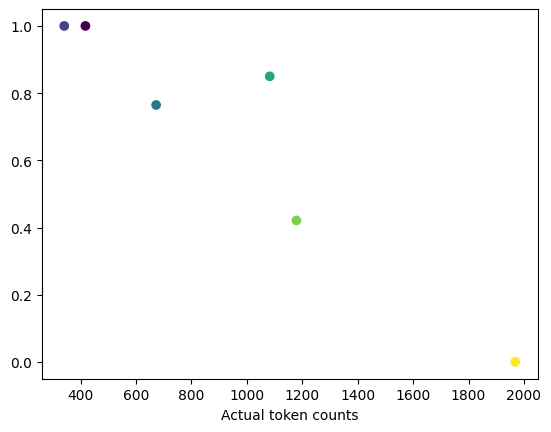

In [94]:

from matplotlib import pyplot as plt


tc = df.groupby("level")["actual_tokens"].mean().sort_index()
acc = df.groupby("level")["is_correct"].mean().sort_index()

assert (tc.index == acc.index).all() 

fig, ax = plt.subplots()

ax.scatter(tc, acc, c=tc.index)
ax.set_xlabel("Actual token counts")

In [106]:
row = df[df["level"] == 6.0].sample(1).iloc[0, :]


gen_text = row["generated_text"]
expected = row["solution"]
print(row["generated_text"])

print("\n\n\n")

print(f'Solution = {row["solution"]}')

<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of▁sen

In [ ]:


def evaluate_answer(expected_answer, generated_answer):
    gen_val = extract_boxed(generated_answer)
    if gen_val is None:
        return False

    exp_val = extract_boxed(expected_answer)
    if exp_val is None:
        exp_val = str(expected_answer).strip()

    return is_equiv(gen_val, exp_val)

for i in df.index[df["level"] == 6.0]:

    prev = df.loc[i, "is_correct"]
    af = evaluate_answer(df.loc[i, "solution"], df.loc[i, "generated_text"])

    if af != prev:
        print(df.loc[i, "question_id"])
        df.loc[i, "is_correct"] = af
        


False True
False True
False True
False True
False True


In [33]:
df["is_correct"].value_counts(normalize=True)

is_correct
True     0.660714
False    0.339286
Name: proportion, dtype: float64

In [37]:
df["question_id"].tolist()

['1262',
 '1281',
 '1284',
 '1294',
 '1328',
 '1422',
 '1494',
 '1668',
 '836',
 '883',
 '905',
 '938',
 '943',
 '960',
 '1009',
 '1011',
 '2244',
 '2247',
 '2294',
 '2307',
 '2377',
 '2444',
 '2460',
 '2464',
 '4865',
 '4906',
 '4937',
 '5087',
 '1986-12',
 '1988-2',
 '1988-15',
 '1989-13',
 '2008-I-6',
 '2009-I-3',
 '2009-II-7',
 '2010-II-4',
 '2010-II-12',
 '2011-I-10',
 '2012-I-11',
 '2014-I-10',
 '4201',
 '4381',
 '4474',
 '4580',
 '4589',
 '4742',
 '4774',
 '4778',
 '302',
 '314',
 '319',
 '421',
 '430',
 '488',
 '532',
 '567',
 '634',
 '704',
 '742',
 '774',
 '775',
 '782',
 '797',
 '799',
 '1698',
 '1719',
 '1736',
 '1741',
 '1769',
 '1792',
 '2120',
 '2158',
 '139',
 '144',
 '164',
 '211',
 '216',
 '254',
 '260',
 '292',
 '2',
 '12',
 '30',
 '80',
 '96',
 '103',
 '110',
 '114',
 '1993-8',
 '1995-15',
 '1999-1',
 '1999-12',
 '1999-13',
 '2000-I-12',
 '2000-II-14',
 '2002-II-11',
 '1020',
 '1028',
 '1064',
 '1138',
 '1197',
 '1212',
 '1220',
 '1238',
 '3321',
 '3705',
 '3736',
 

In [ ]:

import numpy as np

df = df.sort_values(["question_id", "step_i"])
ignore_cols = ["step_i", "problem", "expected_solution"]

out = []

for qid, qdf in df.groupby("question_id"):

    correct = qdf["is_correct"].unique()
    correct = [c for c in correct if (c is not None)]

    assert len(correct) < 2, correct

    # Did not answer within limits
    if len(correct) == 0:
        row = qdf.iloc[-1, :]
    else:
        (inds,) = np.where(qdf["is_correct"] == correct[0])
        i = inds.min()
        row = qdf.iloc[i, :]

    row = row.drop(ignore_cols)
    out.append(row.to_dict())


out = pd.DataFrame(out)
out


    
    

,question_id,target_tokens,actual_tokens,is_correct,generated_text,bin_100,bin_366,bin_633,bin_900,bin_1166,bin_1433,bin_1700,bin_1966,bin_2233,bin_2500
0,1013,100,4050,None,,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2108,100,180,False,Given that\n$\frac 1{2!17!}+\frac 1{3!16!}+\fr...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
df["is_correct"]

0       True
2       True
4       True
6       True
8       True
       ...  
153    False
155    False
157    False
159    False
161    False
Name: is_correct, Length: 162, dtype: bool

In [76]:
# df = pd.read_parquet("../dynamic_regressor_results/batch_1.parquet")

# one = df[df["question_id"] == df["question_id"].sample(1).values[0]]
# one = one.drop(columns="expected_solution")

# with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
#     display(one.sort_values("step_i"))

In [54]:
df = pd.read_parquet("../static_regressor_results/batch_1.parquet")
df

,question_id,problem,expected_solution,target_tokens,actual_tokens,is_correct,generated_text,bin_100,bin_366,bin_633,bin_900,bin_1166,bin_1433,bin_1700,bin_1966,bin_2233,bin_2500
0,9020,Determine the number of ways to arrange the le...,First we count the arrangements if the three E...,100,282,True,<｜end▁of▁sentence｜><｜end▁of▁sentence｜><｜end▁of...,0.991116,0.997639,0.999364,0.996697,0.992203,0.996167,0.969323,0.992358,0.999215,0.998021
1,9054,A singles tournament had six players. Each pla...,"Each of the six players played 5 games, and ea...",100,216,True,<｜begin▁of▁sentence｜>A singles tournament had ...,0.965163,0.985205,0.998298,0.997297,0.994144,0.997904,0.997813,0.996939,0.998123,0.996414


In [24]:
import pandas as pd
df = pd.read_parquet("../data/test.parquet", columns=['question_id', 'target_think_tokens', 'generated_think_tokens', 'is_correct', 'level'])

In [23]:
df.shape[0]

1200

In [ ]:

a

,ID,Year,Problem Number,Question,Answer,Part
0,1983-1,1983,1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,None
1,1983-2,1983,2,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,None
2,1983-3,1983,3,What is the product of the real roots of the e...,20,None
3,1983-4,1983,4,A machine-shop cutting tool has the shape of a...,26,None
4,1983-5,1983,5,Suppose that the sum of the squares of two com...,4,None
...,...,...,...,...,...,...
928,2024-II-11,2024,11,Find the number of triples of nonnegative inte...,601,II
929,2024-II-12,2024,12,"Let $O(0,0),A(\tfrac{1}{2},0),$ and $B(0,\tfra...",23,II
930,2024-II-13,2024,13,Let $\omega\neq 1$ be a 13th root of unity. Fi...,321,II
931,2024-II-14,2024,14,Let $b \geq 2$ be an integer. Call a positive ...,211,II


,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...
...,...,...,...,...
12495,If $\sin x + \cos x = \frac{1}{5}$ and $0 < x ...,Level 5,Precalculus,"From the given equation, $\cos x = \frac{1}{5}..."
12496,The matrix for projecting onto a certain plane...,Level 5,Precalculus,Since $\begin{pmatrix} a \\ b \\ c \end{pmatri...
12497,"Let $\mathbf{a},$ $\mathbf{b},$ and $\mathbf{c...",Level 4,Precalculus,Since $\mathbf{a} + \mathbf{b} + \mathbf{c} = ...
12498,Find the smallest positive integer solution to...,Level 5,Precalculus,"By the tangent addition formula,\n\begin{align..."


In [ ]:
from pathlib import Path


data_folder = Path(".").resolve().parent / "data"

qids = pd.read_parquet(data_folder / "test.parquet", columns=['question_id'])["question_id"].unique()

m = pd.read_parquet(data_folder / "math.parquet", columns=["problem", "solution"])
m = m.reset_index(names="question_id")
m["question_id"] = m["question_id"].astype("string")

a = pd.read_parquet(data_folder / "aime.parquet", columns=["ID", "Question", "Answer"])
a = a.rename(columns={"ID": "question_id", "Question": "problem", "Answer": "solution"})

df = pd.concat((m, a), ignore_index=True)

tqids = set(qids)
aqids = set(df["question_id"])

assert len(tqids - aqids) == 0, "Some question ids are not present in the database"

In [30]:
len(tqids)

120

In [126]:
q = df.drop_duplicates(["question_id", "target_think_tokens"], keep="first")
q = q.rename(columns={"generated_think_tokens": "actual_think_tokens"})


bins = np.sort(q["target_think_tokens"].unique())

correct = q[["is_correct", "target_think_tokens", "question_id"]].copy()

correct["is_correct"] = (
    correct["is_correct"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

correct = pd.pivot(correct, index="question_id", columns="target_think_tokens", values="is_correct")
correct = correct.astype(float).fillna(0)
correct = correct.sort_index(axis="columns")

In [127]:
q["is_correct"].value_counts(normalize=True)

is_correct
True     0.694387
False    0.305613
Name: proportion, dtype: float64

In [121]:
(correct == 1.0).sum().sum() / (correct.shape[0] * correct.shape[1]) 

np.float64(0.667900826446281)

In [104]:
(correct.shape[0] * correct.shape[1]), q.shape[0]

(30250, 30218)

In [112]:
(q.groupby(["question_id", "target_think_tokens"])["is_correct"].nunique() > 1).any()

np.False_

In [92]:
df.duplicated(["question_id", "target_think_tokens"], keep="first").sum()

np.int64(40)

In [71]:
df["is_correct"].value_counts(normalize=True)

is_correct
True     0.668022
False    0.331978
Name: proportion, dtype: float64

In [73]:
np.arange(10).astype(str)

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U21')

In [64]:
df["question_id"].str.split("-", expand=True)[1].unique()

array([None, '2', '8', '10', '14', '15', '1', '3', '11', '12', '13', '4',
       '6', '9', '5', '7', 'I', 'II'], dtype=object)

In [10]:
import numpy as np
df = pd.DataFrame()

bins = tuple([1, 100, 200, 300])
p = np.random.random((10, 4))


df[[str(b) for b in bins]] = p

df

,1,100,200,300
0,0.871158,0.354660,0.206785,0.863632
1,0.715951,0.619435,0.290597,0.457231
2,0.986832,0.626509,0.923971,0.761864
3,0.411031,0.513804,0.639796,0.065070
4,0.412107,0.901580,0.245362,0.889597
5,0.958261,0.026831,0.265811,0.354209
6,0.891172,0.164918,0.363220,0.648321
7,0.049050,0.098297,0.008166,0.382871
8,0.326947,0.155488,0.271333,0.105960
9,0.545817,0.181206,0.849246,0.893569


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

def load_df() -> pd.DataFrame:

    dfs = []
    path =  (Path(".") / "dataset" / "hidden").resolve()
    for path in path.glob("*.csv"):
        dfs.append(pd.read_csv(path))

    return pd.concat(dfs, ignore_index=True)

df = load_df()

In [23]:
df.sample(4)

,question_id,sample_idx,token_step,target_think_tokens,is_correct
65344,886,34,2300,1700,False
174495,1828,44,250,1166,True
105723,28,26,200,633,True
243827,345,2,1100,2233,True


In [24]:
df["question_id"].unique().size

1888

In [28]:
df.tail()

,question_id,sample_idx,token_step,target_think_tokens,is_correct
355430,264,25,2650,2500,True
355431,264,25,2700,2500,True
355432,264,25,2750,2500,True
355433,264,25,2800,2500,True
355434,264,25,2850,2500,True


target_think_tokens,100,366,633,900,1166,1433,1700,1966,2233,2500
question_id,,,,,,,,,,
0,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1,0.000000,0.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000
2,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
3,0.111111,0.000000,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
4,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
...,...,...,...,...,...,...,...,...,...,...
1883,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1884,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
1885,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000


In [85]:
np.sum(correct, axis=1)

question_id
0       10.0
1        8.0
2       10.0
3        9.0
4       10.0
        ... 
1883    10.0
1884    10.0
1885    10.0
1886    10.0
1887     7.0
Length: 1888, dtype: float64

In [ ]:
q

,question_id,sample_idx,target_think_tokens,is_correct,actual_think_tokens
0,1030,0,1166,True,1050
1,1030,1,1433,True,1500
2,1030,2,1700,True,2100
3,1030,3,1966,True,1800
4,1030,4,2233,True,2100
...,...,...,...,...,...
18870,268,59,900,True,400
18871,268,60,1166,True,900
18872,268,61,1433,True,1200
18873,268,62,1700,True,1550


In [93]:
h = np.load("./innit_hidden_states/hidden_states.npy").astype(np.float32)
h_ids = np.arange(h.shape[0])

,question_id,sample_idx,target_think_tokens,is_correct,actual_think_tokens
0,1030,0,1166,True,1050
1,1030,1,1433,True,1500
2,1030,2,1700,True,2100
3,1030,3,1966,True,1800
4,1030,4,2233,True,2100
...,...,...,...,...,...
1882,617,26,100,False,250
1883,617,27,366,False,300
1884,617,28,633,False,250
1885,617,29,900,False,600


In [ ]:


def create_regressor_dataset(h: np.ndarray, h_ids: np.ndarray, df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:

    actual = df.groupby(["question_id", "target_think_tokens"])["token_step"].max().reset_index()
    q = df.drop_duplicates(["question_id", "target_think_tokens"], keep="first")
    q = q.drop(columns="token_step")
    q = pd.merge(q, actual, "left", ["question_id", "target_think_tokens"], validate="1:1")
    q = q.rename(columns={"token_step": "actual_think_tokens"})

    correct = q[["is_correct", "target_think_tokens", "question_id"]].copy()
    correct["is_correct"] = correct["is_correct"].astype(np.bool_)
    correct = pd.pivot(correct, index="question_id", columns="target_think_tokens", values="is_correct")
    correct = correct.astype(float).fillna(0)
    correct = correct.sort_index(axis="columns" )

    q = q.loc[q.index.isin(h_ids)]

    return np.squeeze(h), correct.to_numpy(), tuple(correct.columns.astype(int).tolist())

h = np.load("./innit_hidden_states/hidden_states.npy").astype(np.float32)
h_ids = np.arange(h.shape[0])
x, y = create_regressor_dataset(h, h_ids, df)
x.shape, y.shape


[100, 366, 633, 900, 1166, 1433, 1700, 1966, 2233, 2500]


((1887, 1536), (1888, 10))

In [ ]:
import numpy as np

z = np.random.randint(0, 2, size=(3, 10)).astype(np.bool)




[[ True False False False  True  True  True False False False]
 [False False False  True  True  True  True  True False  True]
 [ True  True False  True False False  True False  True  True]]


(array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2]),
 array([0, 4, 5, 6, 3, 4, 5, 6, 7, 9, 0, 1, 3, 6, 8, 9]))

100%|██████████| 10000/10000 [03:55<00:00, 42.38it/s]


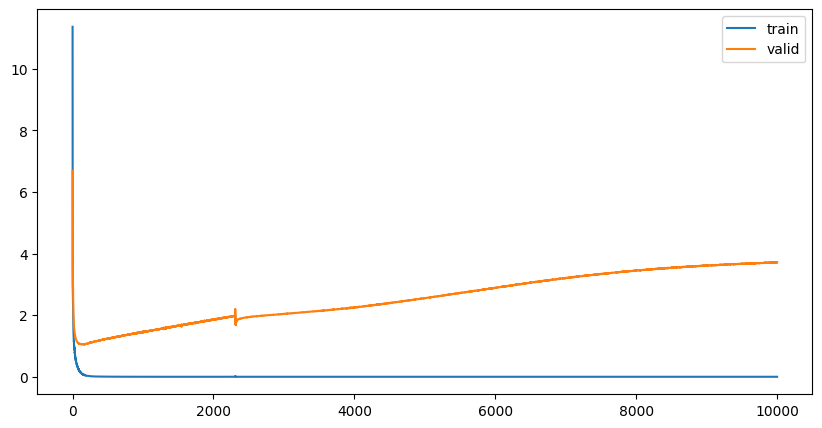

In [123]:
from typing import Generator
import jax
import optax
import jax.numpy as jnp
import flax
import tqdm
from functools import partial

@flax.struct.dataclass
class Network:
    layers: tuple[tuple[jax.Array, jax.Array]]


def forward(x: jax.Array, network: Network) -> jax.Array:
    
    h = x
    for w, b in network.layers[:-1]:
        h = h @ w.T + b 
        h = jax.nn.relu(h)
    
    w, b = network.layers[-1]
    logits = h @ w.T + b 
    return logits


def loss(
    network: Network,
    x: jax.Array,
    y: jax.Array,
):
    yhat = forward(x, network)
    return optax.sigmoid_binary_cross_entropy(yhat, y).mean()

def train_step(
    x: jax.Array,
    y: jax.Array,
    network: Network,
    opt_state: jax.Array,
    optimizer: optax.GradientTransformationExtraArgs
) -> tuple[jax.Array, Network, jax.Array]:

    l, grad = jax.value_and_grad(loss)(network, x, y)
    updates, opt_state = optimizer.update(grad, opt_state, network)
    network = optax.apply_updates(network, updates)

    return l, network, opt_state
    
@jax.jit
def valid_step(
    x: jax.Array,
    y: jax.Array,
    network: Network,
) -> tuple[jax.Array, Network, jax.Array]:
    l = loss(network, x, y)
    return l


def init_mlp(layers: list[int], key: jax.Array) -> tuple[tuple[jax.Array, jax.Array]]:

    arch = []

    initializer = jax.nn.initializers.he_normal()
    keys = jax.random.split(key, len(layers) - 1)
    
    for prev, fol, k in zip(layers[:-1], layers[1:], keys, strict=True):

        wkey, bkey = jax.random.split(k, 2)

        w = initializer(wkey, (fol, prev))
        b = jax.random.normal(bkey, shape=(fol,)) * (1e-3)

        arch.append((w, b))

    return tuple(arch)


def batch_dataset(x: np.ndarray, y: np.ndarray, batch: int, shuffle: bool = False) -> Generator[tuple[np.ndarray, np.ndarray], None, None]:
    
    n = x.shape[0]

    if shuffle:
        si = np.random.permutation(n)
        x = x[si, :]
        y = y[si, :]

    n_batches = int(np.ceil(n / batch)) 
    for i_batch in range(n_batches):

        s = i_batch * batch
        e = s + batch

        yield x[s:e, :], y[s:e, :]


def train(
    x: np.ndarray,
    y: np.ndarray,
    epochs: int,
    valid_p: float = 0.1,
    batch_size: int = 128,
):
    

    key = jax.random.key(seed=0)
    kinit, kloop, kvalid, k4, k5, key = jax.random.split(key, 6)
    
    perm = np.random.permutation(x.shape[0])
    train_size = int((1 - valid_p) * x.shape[0])
    train_idx, valid_idx = perm[:train_size], perm[train_size:]
    x_train, y_train = x[train_idx], y[train_idx]
    x_valid, y_valid = x[valid_idx], y[valid_idx]

    
    network = Network(init_mlp(
        layers=[1_536, 256, 256, 256, 10],
        key=kinit
    ))

    optimizer = optax.adamw(1e-4, weight_decay=1e-3)
    opt_state = optimizer.init(network)

    train_step_compiled = jax.jit(partial(train_step, optimizer=optimizer))

    tl = []
    vl = []
    for _ in tqdm.tqdm(range(epochs)):

        k_use_loop, kloop = jax.random.split(kloop, 2) 

        bl = []
        for x_batch, y_batch in batch_dataset(x_train, y_train, batch=batch_size, shuffle=True):
            x_batch = jax.device_put(x_batch)
            y_batch = jax.device_put(y_batch)

            l, network, opt_state = train_step_compiled(x_batch, y_batch, network, opt_state)
            bl.append(l.mean().item())

        

        tl.append(np.mean(bl))
        
        bl = []
        for x_batch, y_batch in batch_dataset(x_valid, y_valid, batch=batch_size):

            x_batch = jax.device_put(x_batch)
            y_batch = jax.device_put(y_batch)

            l = valid_step(x_batch, y_batch, network)

            bl.append(l.mean().item())
        vl.append(np.mean(bl))
    
    return tl, vl


tl, vl = train(x, y, epochs=10_000, batch_size=512)

from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tl, label="train")
ax.plot(vl, label="valid")

ax.legend()
plt.show()
    

In [7]:
import jax
import jax.numpy as jnp

layers = [(jnp.zeros((10, 10)),  jnp.ones(10)), (jnp.ones((5, 5)),)]

# Flatten tree into leaves and treedef
leaves, treedef = jax.tree.flatten(layers)

# Convert each leaf to list (for e.g. JSON compatibility)
pa_leaves = [x.tolist() for x in leaves]

# Rebuild the tree of Python lists
pa = jax.tree.unflatten(treedef, pa_leaves)

# Convert back to JAX arrays, restoring dtype from original leaves
l = jax.tree.unflatten(treedef, [jnp.array(x, dtype=orig.dtype)
                                 for x, orig in zip(pa_leaves, leaves)])
l

[(Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
  Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)),
 (Array([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]], dtype=float32),)]

In [10]:
jnp.array([2]).mean()

Array(2., dtype=float32)

In [11]:
jax.devices('cpu')

[CpuDevice(id=0)]